# Online Retail Sales & Customer Analysis

**Author:** Bervely Pangwana
**Dataset:** Online Retail II (UCI Machine Learning Repository)
https://archive.ics.uci.edu/dataset/502/online+retail+ii

This notebook cleans real e-commerce transaction data, explores revenue and product trends, and segments customers using RFM analysis. Outputs feed into a Power BI / Tableau dashboard.


## 1. Load Data

Make sure the downloaded `.xlsx` file is in the same folder as this notebook, and update the filename below if needed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2009-2010")

print("Initial shape:", df.shape)
df.head()

Initial shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


## 2. Clean Data

Steps:
- Drop rows with missing Customer ID (can't attribute these to a customer)
- Remove cancelled orders (Invoice numbers starting with "C")
- Remove non-positive Quantity or Price (returns/errors/free items)
- Remove exact duplicate rows
- Add a TotalPrice column
- Ensure InvoiceDate is a proper datetime

In [5]:
df = df.dropna(subset=["Customer ID"])
df = df[~df["Invoice"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
df = df.drop_duplicates()

df["TotalPrice"] = df["Quantity"] * df["Price"]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (400916, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## 3. Exploratory Analysis

### Monthly Revenue Trend

C:\Users\SIBUSISIWE\AppData\Local\Temp\ipykernel_21624\3235722004.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.set_index("InvoiceDate").resample("M")["TotalPrice"].sum()


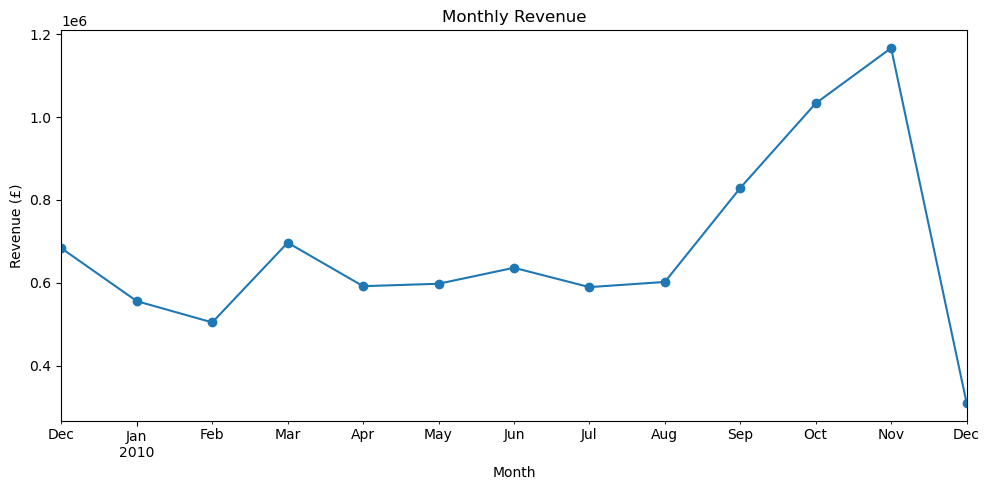

In [7]:
monthly_revenue = df.set_index("InvoiceDate").resample("M")["TotalPrice"].sum()

plt.figure(figsize=(10, 5))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue")
plt.ylabel("Revenue (£)")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig("monthly_revenue.png")
plt.show()

* Revenue starts a rapid growth from the month of August and is at its peak in November but there is a drastic drop in from the peak revenue to December which is the month with the least revenue *

### Top 10 Products by Revenue

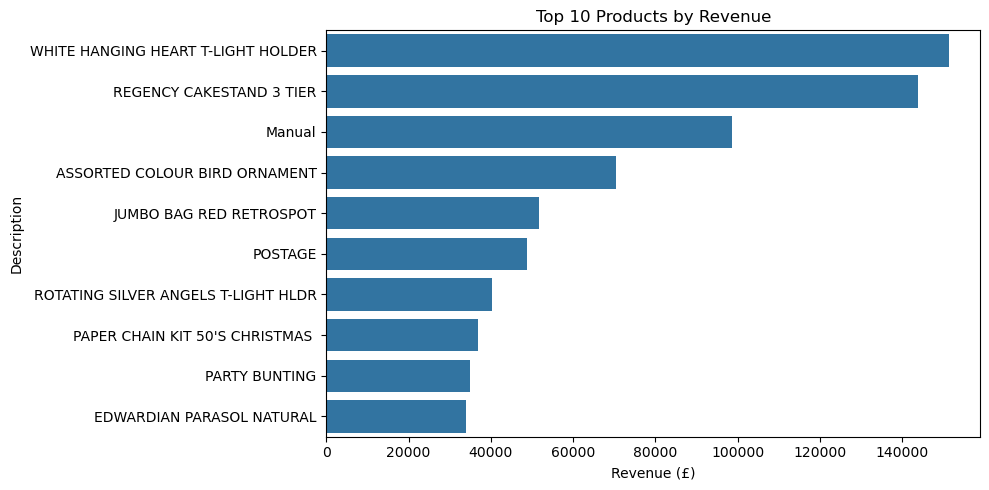

In [9]:
top_products = (
    df.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.tight_layout()
plt.savefig("top_products.png")
plt.show()

### Top 10 Countries by Revenue

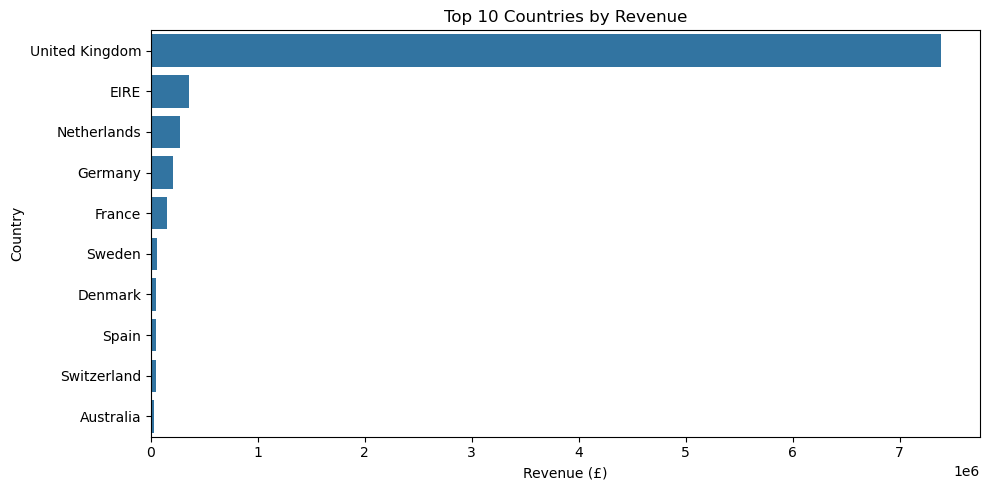

In [11]:
top_countries = (
    df.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.tight_layout()
plt.savefig("top_countries.png")
plt.show()

## 4. RFM Analysis (Recency, Frequency, Monetary)

This segments customers based on:
- **Recency** — how recently they purchased
- **Frequency** — how often they purchase
- **Monetary** — how much they spend

This is a real technique used in marketing/BI roles to identify high-value customers and those at risk of churning.

In [13]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalPrice", "sum"),
)

rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5])

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,165,11,372.86,2,5,2,252
12347.0,3,2,1323.32,5,2,4,524
12348.0,74,1,222.16,2,1,1,211
12349.0,43,3,2671.14,3,3,5,335
12351.0,11,1,300.93,5,1,2,512


In [15]:
def segment_customer(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "High Value"
    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "At Risk"
    elif row["F_Score"] <= 2 and row["R_Score"] >= 4:
        return "New Customer"
    else:
        return "Regular"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

rfm["Segment"].value_counts()

Segment
Regular         2004
At Risk         1015
High Value       926
New Customer     367
Name: count, dtype: int64

*Check if these segment thresholds make sense for your actual data distribution — adjust the logic in `segment_customer()` if one segment ends up empty or too dominant.*

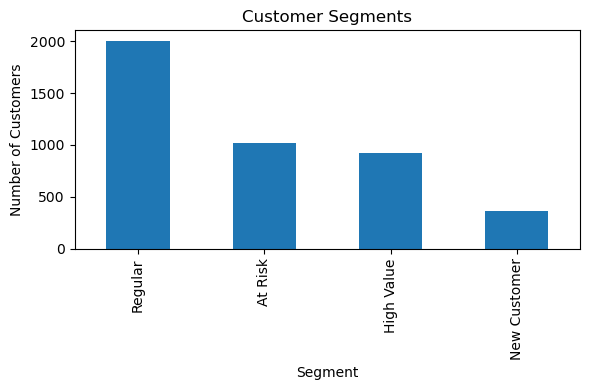

In [17]:
plt.figure(figsize=(6, 4))
rfm["Segment"].value_counts().plot(kind="bar")
plt.title("Customer Segments")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("customer_segments.png")
plt.show()

## 5. Export Cleaned Data for Power BI / Tableau

In [19]:
df.to_csv("cleaned_retail_data.csv", index=False)
rfm.to_csv("customer_rfm_segments.csv")

print("Exported: cleaned_retail_data.csv, customer_rfm_segments.csv")

Exported: cleaned_retail_data.csv, customer_rfm_segments.csv


## 6. Key Findings (fill this in once you've run everything)

- Revenue trend: ...
- Top products: ...
- Top markets: ...
- Customer segments: ...% High Value, ...% At Risk, etc.

*Next step: bring `cleaned_retail_data.csv` and `customer_rfm_segments.csv` into Power BI or Tableau to build the interactive dashboard.*